In [2]:
import os
import sys
if os.path.abspath('../src') not in sys.path:
    sys.path.append(os.path.abspath('../src'))
# os.environ["PYTHONPATH"] = '/opt/venv/lib/python3.11/site-packages'

import gc
import logging
import multiprocessing
import pickle
import time
from functools import partial
from pathlib import Path
from typing import Any, Literal

import dgl
import numpy as np
import pandas as pd
import pysmiles
import torch
from datasets import Dataset, IterableDataset, disable_caching, load_dataset, load_from_disk
from dgl.dataloading import GraphDataLoader
from dgl.heterograph import DGLGraph
from easydict import EasyDict
from rdkit import Chem
from tqdm.auto import tqdm
import lancedb
import pyarrow as pa

from data_processing import mol_to_dgl, networkx_to_dgl
from model import GNN
from interface import MolRSmilesEmbedder
logging.getLogger('pysmiles').setLevel(logging.CRITICAL)

from multiprocess import set_start_method
try:
    set_start_method("spawn")
except RuntimeError as e:
    print(e)

disable_caching()  # disables caching for datasets

context has already been set


In [3]:
MODEL_PATH = Path('../saved/tag_1024')
DATA_PATH = Path("/mnt/sagemaker-nvme/CS2/train.csv")

embedder = MolRSmilesEmbedder(MODEL_PATH)
dataset = load_dataset('csv', data_files=str(DATA_PATH), split='train')
emb_dataset = load_from_disk(DATA_PATH.parent / 'all_embeddings')
dimension = len(emb_dataset[0]['vector'])
print(f"embedding dimension: {dimension}")

embedding dimension: 1024


In [4]:
uri = "/mnt/sagemaker-nvme/lancedb_demo"
db = lancedb.connect(uri)


In [5]:
def create_schema_from_dataset(
    dataset: Dataset | IterableDataset, dimension: int, only_fields: list[str] | None = None):
    schema = dataset.features.arrow_schema.remove_metadata()
    
    # replace the vector field if it already exists with a fixed size list
    idx = schema.get_field_index("vector")
    if idx != -1:
        schema = schema.remove(schema.get_field_index("vector"))
    schema = schema.insert(0, pa.field("vector", pa.list_(pa.float32(), list_size=dimension)))
    
    # remove all fields that are not in the only_fields list
    all_fields = dataset.features.keys()
    if only_fields is not None:
        for field in all_fields:
            if field not in only_fields:
                schema = schema.remove(schema.get_field_index(field))
    return schema


In [6]:
schema = create_schema_from_dataset(emb_dataset, dimension)
db.drop_table("chembl", ignore_missing=True)
tbl = db.create_table("chembl", schema=schema)

In [7]:
start = time.time()
tbl.add(emb_dataset)
end = time.time()
import_time = end - start
print(f"Time to import data into db: {import_time:.2f} seconds")

Time to import data into db: 24.22677493095398


In [8]:
start = time.time()
tbl.create_index(
    num_partitions=int(np.sqrt(len(emb_dataset))),  # number of centroids
    num_sub_vectors=64,                             # divisor of the vector dimension
    accelerator="cuda"                              # build kNN index on GPU
)
end = time.time()
indexing_time = end - start
print(f"Indexing time: {indexing_time:.2f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

/opt/venv/lib/python3.11/site-packages/lance/torch/data.py:60: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  tensor = torch.from_numpy(np_tensor)
100%|██████████| 1026538/1026538 [00:10<00:00, 94923.95it/s] 


Indexing time: 231.15 seconds


In [9]:
def extract_centroids(dataset):
    index_name = dataset.list_indices()[0]["name"]
    index_stats = dataset.index_statistics(index_name)
    n_indices = len(index_stats["indices"])
    if n_indices > 1:
        raise ValueError(f"Only one index is supported, got {n_indices}")
    n_dim = index_stats["indices"][0]['sub_index']["dimension"]
    centroids_values = pa.array(
        [x for c in index_stats['indices'][0]["centroids"] for x in c],
        pa.float32(),
    )
    return pa.FixedSizeListArray.from_arrays(centroids_values, n_dim)


In [10]:
centroids = extract_centroids(tbl._dataset)

In [11]:
tbl.search(centroids[0].values.to_numpy()).limit(5).select(["smiles", "main_reward"]).to_list()

[{'smiles': 'CN1CCN(c2cccc(Nc3ncc4c(n3)-c3c(c(C(N)=O)cn3C)CC4)c2)CC1',
  'main_reward': -7.599388208354957,
  '_distance': 227.6892852783203},
 {'smiles': 'CN1CCN(c2ccc(Nc3ncc4c(n3)-c3c(c(C(N)=O)cn3C)CC4)cc2)CC1',
  'main_reward': -7.591904318537583,
  '_distance': 237.1512451171875},
 {'smiles': 'COc1ccccc1N1CCN(c2cccc3c2nc(-c2cncc(C#N)c2)n3CCNCc2ccccc2)CC1',
  'main_reward': -7.698816588654292,
  '_distance': 241.7882080078125},
 {'smiles': 'COc1ccccc1N1CCN(c2cccc3c2nc(-c2cncc(C#N)c2)n3CCNCc2ccccc2)CC1',
  'main_reward': -7.698816588654292,
  '_distance': 241.7882080078125},
 {'smiles': 'Cn1cc(C(N)=O)c2c1-c1nc(Nc3ccc(N4CCOCC4)cc3)ncc1CC2',
  'main_reward': -1.3314130160310746,
  '_distance': 245.01046752929688}]

In [12]:
def test_search_speed(table, dataset, batch_sizes=[16, 32, 64, 128], num_retries=5):
    times = []
    accuracies_top1 = []
    accuracies_top5 = []
    for batch_size in tqdm(batch_sizes, leave=False, desc='batch_size', position=0):
        times_per_run = []
        accuracies_top1_per_run = []
        accuracies_top5_per_run = []
        for _ in range(num_retries):
            random_indices = np.random.randint(0, len(dataset) - 1, batch_size)
            random_smiles = [dd for dd in dataset.select(random_indices)['smiles']]
            data = [vec for vec in dataset.select(random_indices)['vector']]
            start = time.time()
            res = [table.search(vec).limit(5).select(["smiles", "main_reward"]).to_list() for vec in data]
            end = time.time()
            times_per_run.append(end - start)
            retrieved_smiles_top1 = [per_query[0]['smiles'] for per_query in res]
            retrieved_smiles_top5 = [dd['smiles'] for per_query in res for dd in per_query]
            accuracies_top1_per_run.append(len(set(retrieved_smiles_top1).intersection(set(random_smiles))) / batch_size)
            accuracies_top5_per_run.append(len(set(retrieved_smiles_top5).intersection(set(random_smiles))) / batch_size)
        times.append(np.mean(times_per_run))
        accuracies_top1.append(np.mean(accuracies_top1_per_run))
        accuracies_top5.append(np.mean(accuracies_top5_per_run))
    result = pd.DataFrame({'batch_size': batch_sizes, 'time': times, 'accuracy_top1': accuracies_top1, 'accuracy_top5': accuracies_top5})
    result['time_per_mol'] = result['time'] / result['batch_size']
    return result

In [13]:
results = test_search_speed(tbl, emb_dataset, batch_sizes=[16, 32, 64, 128], num_retries=5)

<Axes: title={'center': 'Search time per molecule'}, xlabel='batch size', ylabel='time (s)'>

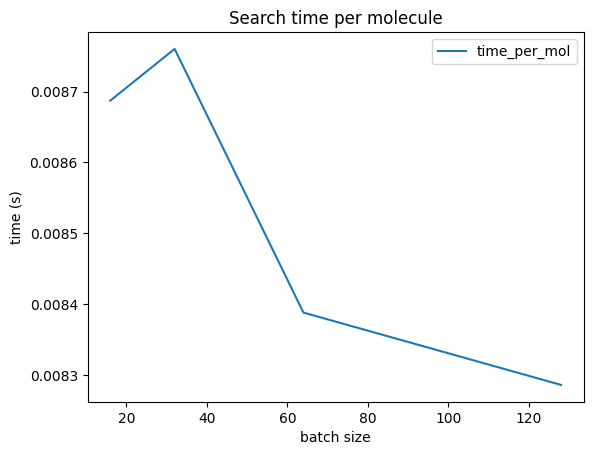

In [14]:
results.plot(x='batch_size', y='time_per_mol', title='Search time per molecule', ylabel='time (s)', xlabel='batch size')

<Axes: title={'center': 'Top 1 recall'}, xlabel='batch size', ylabel='recall'>

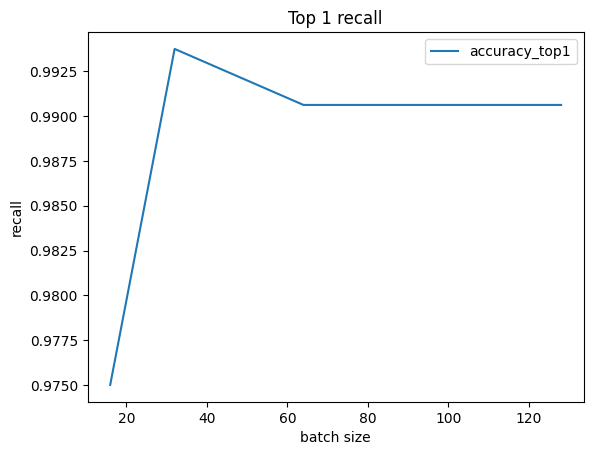

In [15]:
results.plot(x='batch_size', y='accuracy_top1', title='Top 1 recall', ylabel='recall', xlabel='batch size')